In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset
import requests
from io import BytesIO
import os
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

In [13]:
#Importar el dataset
df = pd.read_csv('../data/Deepfake.csv')

In [14]:
#crear funcion para descargar las imagenes de las url
def preprocess_image(url):
    try:
        response = requests.get(url, timeout=10)

        if response.status_code != 200:
            return None

        img = Image.open(BytesIO(response.content))
        img = img.convert("RGB")

        return img

    except Exception:
        return None

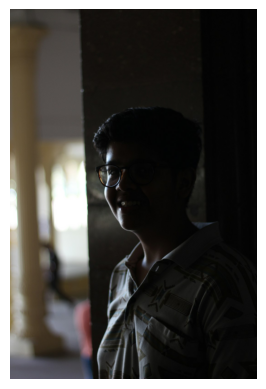

In [15]:
df['image'] = df['image_url'].apply(preprocess_image)

plt.imshow(df['image'].iloc[1])
plt.axis("off")
plt.show()

In [16]:
#Eliminar los valores nulos
df = df[df['image'].notna()]

In [17]:
os.makedirs("../data/processed/real", exist_ok=True)
os.makedirs("../data/processed/fake", exist_ok=True)

In [18]:
metadata = []

for idx, row in df.iterrows():

    image = row["image"]
    label = row["label"]

    folder = "real" if label == 'REAL' else "fake"

    image_path = f"../data/processed/{folder}/{idx}.jpg"

    image.save(image_path)

    metadata.append({
        "image_path": image_path,
        "label": label
    })

In [19]:
metadata_df = pd.DataFrame(metadata)

metadata_df.to_csv(
    "../data/metadata.csv",
    index=False
)

In [20]:
del df

In [23]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [24]:
class DeepfakeDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        image_path = self.df.iloc[idx]["image_path"]
        label = self.df.iloc[idx]["label"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label)

In [25]:
dataset = DeepfakeDataset(
    metadata_df,
    transform=train_transforms
)

train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [26]:
train_df, temp_df = train_test_split(
    metadata_df,
    test_size=0.30,
    stratify=metadata_df["label"],
    random_state=42
)

# Temp -> Validation 15% + Test 15%
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

In [27]:
print(f"Train: {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Test: {len(test_df)}")

Train: 3889
Validation: 834
Test: 834


In [28]:
print(train_df["label"].value_counts(normalize=True))
print(val_df["label"].value_counts(normalize=True))
print(test_df["label"].value_counts(normalize=True))

label
REAL    0.502186
FAKE    0.497814
Name: proportion, dtype: float64
label
REAL    0.502398
FAKE    0.497602
Name: proportion, dtype: float64
label
REAL    0.501199
FAKE    0.498801
Name: proportion, dtype: float64


In [29]:
train_df.to_csv("../data/train.csv", index=False)
val_df.to_csv("../data/val.csv", index=False)
test_df.to_csv("../data/test.csv", index=False)